In [51]:
# ––– Irish Financial Literacy Analysis ––––
# Companion analysis to the Excel dashboard
# Data source: OECD/INFE 2023 International Survey of Adult Financial Literacy
# Author: Lucy An Coffey | July 2026

# Importing Libraries
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches 
import seaborn as sns

# Loading Data
# 18-29 country table
df = pd.read_excel("Irish_Financial_Literacy_Project.xlsx", sheet_name="05_Clean_Table")

# knowledge questions sheet
kq = pd.read_excel("Irish_Financial_Literacy_Project.xlsx", sheet_name="02_Knowledge_Questions")

print("Libraries loaded successfully")
print(f"Dataset loaded: {len(df)} countries")
print(f"Knowledge questions loaded: {len(kq)} questions")
print("\nIreland's 18-29 profile:")
print(df[df["Country"].str.strip() == "Ireland"][["Country", "Knowledge_Out_Of_100", "Behaviour_Out_Of_100", "Attitudes_Out_Of_100", "Overall_Score_Out_Of_100"]].to_string(index=False))

Libraries loaded successfully
Dataset loaded: 39 countries
Knowledge questions loaded: 5 questions

Ireland's 18-29 profile:
 Country  Knowledge_Out_Of_100  Behaviour_Out_Of_100  Attitudes_Out_Of_100  Overall_Score_Out_Of_100
Ireland              68.970192             75.686768             57.344543                 69.667519


In [52]:
# Colour Palette 
TEAL = "#0F6E56" # Ireland / primary
TEAL_LIGHT = "#E1F5EE" # Ireland background fills
GREY = "#B0B8B4" # OECD average
DARK = "#1A1A1A" # Text
AMBER = "#BA7517" # Warning / highlight
RED = "#A32D2D" # Below 50% threshold
PURPLE = "#3C3489" # Accent

In [53]:
# OECD averages for Ireland's 18-29 cohort (from 04_Analysis sheet)
OECD_18_29 = {
    "Knowledge":  62.71,
    "Behaviour":  60.14,
    "Attitudes":  54.94,
    "Overall":    60.01
}

# Ireland's 18-29 scores
IRE_18_29 = {
    "Knowledge":  68.97,
    "Behaviour":  75.69,
    "Attitudes":  57.34,
    "Overall":    69.67
}

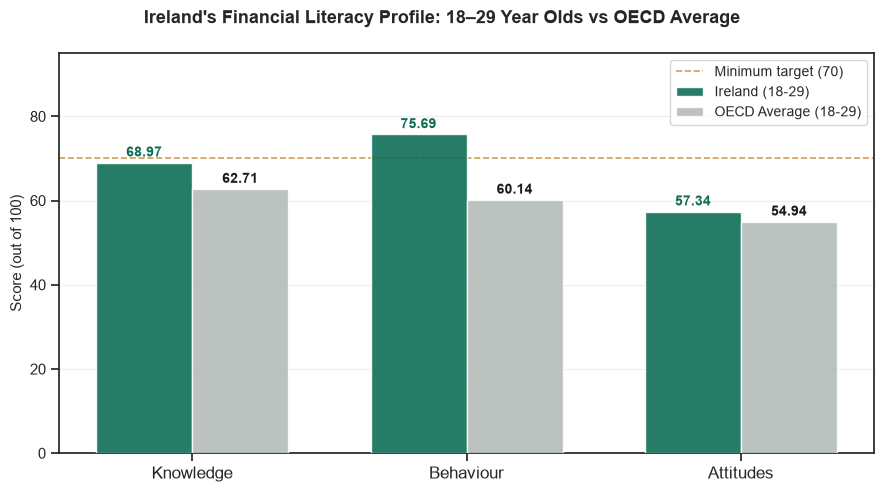

Chart 1 saved as chart1_ireland_profile.png


In [54]:
# --- Chart 1: Ireland 18-29 sub-score profile vs OECD ---

fig, ax = plt.subplots(figsize=(9, 5))

sns.set_theme(style='ticks')

metrics = ['Knowledge', 'Behaviour', 'Attitudes']
ire_scores = [IRE_18_29[m] for m in metrics]
oecd_scores = [OECD_18_29[m] for m in metrics]

x = [0, 1, 2]
width = 0.35

bars_ire = ax.bar([i - width/2 for i in x], ire_scores, width, label="Ireland (18-29)", color=TEAL, alpha=0.9, zorder=3)
bars_oecd = ax.bar([i + width/2 for i in x], oecd_scores, width, label="OECD Average (18-29)", color=GREY, alpha=0.85, zorder=3)

for bar in bars_ire:
    ax.text(bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.8,
        f'{bar.get_height():.2f}',
        ha='center', va='bottom', fontsize=10, fontweight='bold', color=TEAL)

for bar in bars_oecd:
    ax.text(bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.8,
        f'{bar.get_height():.2f}',
        ha='center', va='bottom', fontsize=10, fontweight='bold', color=DARK)

# Minimum target line
ax.axhline(y=70, color=AMBER, linestyle='--', linewidth=1.2, alpha=0.7, label='Minimum target (70)', zorder=2)

ax.set_ylabel('Score (out of 100)', fontsize=11)
ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=12)
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3, zorder=1)
ax.set_ylim(0, 95)

fig.suptitle("Ireland's Financial Literacy Profile: 18–29 Year Olds vs OECD Average", fontsize=13, fontweight='bold')
fig.tight_layout()
plt.savefig('chart1_ireland_profile.png')
plt.show()
print("Chart 1 saved as chart1_ireland_profile.png")

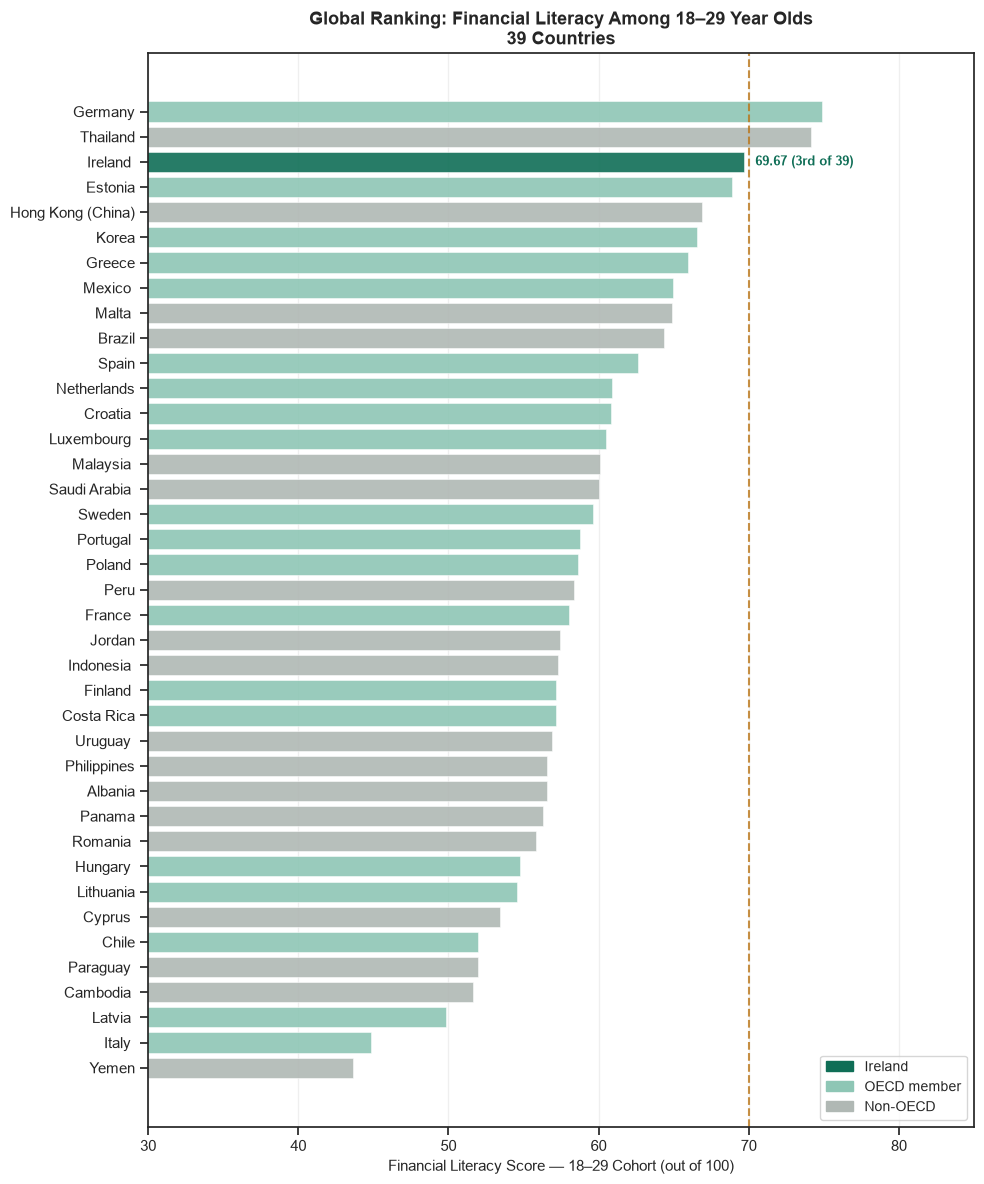

Chart 2 saved as chart2_global_ranking.png


In [62]:
# --- Chart 2: Global ranking of 18-29 cohorts ---

df_sorted = df.sort_values("Overall_Score_Out_Of_100", ascending=True).copy()

# Colour code
def bar_colour(row):
    if row["Country"] == 'Ireland ':
        return TEAL
    elif row['OECD_Member'] == 'Yes':
        return '#8EC6B5' 
    else:
        return GREY

df_sorted['bar_colour'] = df_sorted.apply(bar_colour, axis=1)

fig, ax = plt.subplots(figsize=(10, 12))

bars = ax.barh(
    df_sorted['Country'], 
    df_sorted['Overall_Score_Out_Of_100'], 
    color=df_sorted['bar_colour'], 
    alpha=0.9, edgecolor='white', linewidth=0.4)

# Setting minimum target reference line
ax.axvline(x=70, 
           color=AMBER, 
           linestyle='--', linewidth=1.5, alpha=0.8, 
           label='Minimum target (70)')

# Labelling Ireland's bar
ireland_score = df_sorted[df_sorted['Country'] == 'Ireland ']['Overall_Score_Out_Of_100'].values[0]
ireland_rank = int(df_sorted[df_sorted['Country'] == 'Ireland '].index[0])
ax.text(ireland_score + 0.5, 
        df_sorted['Country'].tolist().index('Ireland '), 
        f' {ireland_score:.2f} (3rd of 39)', 
        va='center', fontsize=9, fontweight='bold', color=TEAL)

# Legend patches
ire_patch = mpatches.Patch(color=TEAL,         label='Ireland')
oecd_patch = mpatches.Patch(color='#8EC6B5', label='OECD member')
other_patch = mpatches.Patch(color=GREY,       label='Non-OECD')

ax.set_xlabel('Financial Literacy Score — 18–29 Cohort (out of 100)', fontsize=11)
ax.set_title('Global Ranking: Financial Literacy Among 18–29 Year Olds\n39 Countries', fontsize=13, fontweight='bold')
ax.legend(handles=[ire_patch, oecd_patch, other_patch], loc='lower right', fontsize=10)
ax.set_xlim(30, 85)
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('chart2_global_ranking.png')
plt.show()
print("Chart 2 saved as chart2_global_ranking.png")